<a href="https://colab.research.google.com/github/prab369/Image_classification/blob/main/Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: prab369
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:06<00:00, 116MB/s]


In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os


device= "cuda" if torch.cuda.is_available() else "cpu"
print("Device available:",device)


Device available: cuda


In [3]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
   for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)
data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path","labels"])
print(data_df["labels"].unique())
data_df.head()


['cat' 'dog' 'wild']


,image_path,labels
0,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
1,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
2,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
3,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


In [4]:
train = data_df.sample(frac=0.7)
test = data_df.drop(train.index)
val = test.sample(frac = 0.5)
test= test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

(11291, 2)
(2420, 2)
(2419, 2)


In [5]:
from inspect import Traceback
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [6]:
class CustomImageDataset(Dataset):
  def __init__(self,dataframe, transform= None):
    self.dataframe= dataframe
    self.transform= transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)
  def __len__(self):
    return self.dataframe.shape[0]
  def __getitem__(self,idx):
    img_path = self.dataframe.iloc[idx,0]
    label = self.labels[idx]
    image = Image.open(img_path).convert('RGB')
    if self.transform:
      image = self.transform(image).to(device)
    return image, label

In [7]:
train_dataset = CustomImageDataset(dataframe=train, transform=transform)
val_dataset = CustomImageDataset(dataframe=val, transform=transform)
test_dataset = CustomImageDataset(dataframe=test, transform=transform)


In [8]:
train_dataset.__getitem__(2)

(tensor([[[0.5843, 0.5804, 0.5765,  ..., 0.5020, 0.5059, 0.5137],
          [0.5961, 0.5922, 0.5843,  ..., 0.4902, 0.4941, 0.5020],
          [0.6039, 0.6000, 0.5961,  ..., 0.4824, 0.4824, 0.4863],
          ...,
          [0.6824, 0.7020, 0.7176,  ..., 0.3451, 0.3412, 0.3294],
          [0.6824, 0.6980, 0.7137,  ..., 0.3412, 0.3451, 0.3373],
          [0.6745, 0.6941, 0.7059,  ..., 0.3333, 0.3412, 0.3294]],
 
         [[0.4824, 0.4784, 0.4745,  ..., 0.4275, 0.4314, 0.4392],
          [0.4941, 0.4902, 0.4824,  ..., 0.4157, 0.4196, 0.4275],
          [0.5020, 0.4980, 0.4941,  ..., 0.4078, 0.4078, 0.4118],
          ...,
          [0.6824, 0.7059, 0.7216,  ..., 0.2784, 0.2745, 0.2627],
          [0.6824, 0.7020, 0.7176,  ..., 0.2745, 0.2784, 0.2706],
          [0.6745, 0.6980, 0.7098,  ..., 0.2667, 0.2745, 0.2627]],
 
         [[0.4235, 0.4196, 0.4157,  ..., 0.3608, 0.3647, 0.3725],
          [0.4353, 0.4314, 0.4235,  ..., 0.3490, 0.3529, 0.3608],
          [0.4431, 0.4392, 0.4353,  ...,

In [9]:
label_encoder.inverse_transform([2])

array(['wild'], dtype=object)

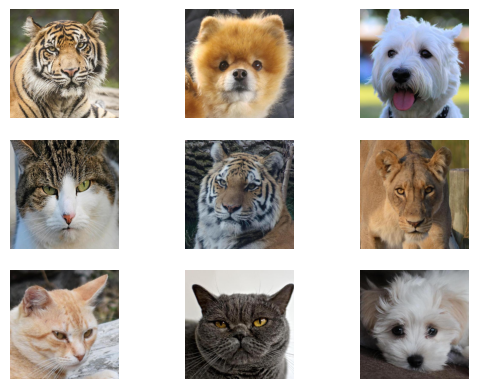

In [10]:
n_rows = 3
n_cols = 3
f, axarr = plt.subplots(n_rows, n_cols)
for row in range(n_rows):
    for col in range(n_cols):
      image = Image.open(data_df.sample(n = 1)['image_path'].iloc[0]).convert("RGB")
      axarr[row, col].imshow(image)
      axarr[row, col].axis('off')

plt.show()

In [11]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [12]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle= True)

In [13]:
class Net(nn.Module):
  def __init__(self):
    super().__init__(),
    self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding=1)
    self.conv2 = nn.Conv2d(32, 64,kernel_size=3,padding=1 )
    self.conv3 = nn.Conv2d(64, 128, kernel_size = 3,padding=1)

    self.pooling = nn.MaxPool2d(2,2)

    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128*16*16),128)

    self.output = nn.Linear(128, len(data_df['labels'].unique()))
  def forward(self,x):
    x= self.conv1(x)#->(32,128,128)
    x = self.pooling(x)#->(32,64,64)
    x = self.relu(x)

    x= self.conv2(x)#(64,64,64)
    x = self.pooling(x)#->(64,32,32)
    x = self.relu(x)

    x= self.conv3(x)#(128,32,32)
    x = self.pooling(x)#->(128,16,16)
    x = self.relu(x)

    x= self.flatten(x)
    x= self.linear(x)
    x= self.output(x)
    return x


In [14]:
model = Net().to(device)


In [15]:
from torchsummary import summary
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [17]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []


for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  total_acc_validation_plot.append(round(total_acc_val/(val_dataset.__len__())*100, 4))
  print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}
              Validation Loss: {round(total_loss_val/100, 4)} Validation Accuracy: {round((total_acc_val)/val_dataset.__len__() * 100, 4)}''')
  print("="*25)

Epoch 1/10, Train Loss: 3.1863 Train Accuracy 81.0823
              Validation Loss: 0.5166 Validation Accuracy: 87.2314
Epoch 2/10, Train Loss: 1.2445 Train Accuracy 93.6321
              Validation Loss: 0.2308 Validation Accuracy: 94.6281
Epoch 3/10, Train Loss: 0.8022 Train Accuracy 96.0588
              Validation Loss: 0.1837 Validation Accuracy: 95.2893
Epoch 4/10, Train Loss: 0.5425 Train Accuracy 97.1925
              Validation Loss: 0.2162 Validation Accuracy: 94.7107
Epoch 5/10, Train Loss: 0.4026 Train Accuracy 98.0073
              Validation Loss: 0.1828 Validation Accuracy: 95.6198
Epoch 6/10, Train Loss: 0.2863 Train Accuracy 98.5475
              Validation Loss: 0.1645 Validation Accuracy: 96.157
Epoch 7/10, Train Loss: 0.195 Train Accuracy 99.0701
              Validation Loss: 0.1981 Validation Accuracy: 96.281
Epoch 8/10, Train Loss: 0.1502 Train Accuracy 99.3623
              Validation Loss: 0.2043 Validation Accuracy: 96.1983
Epoch 9/10, Train Loss: 0.1162 Trai

In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs , labels in test_loader:
    predictions = model(inputs)
    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    test_loss = criterion(predictions, labels)
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()
print(f"Accuracy Score is: { round(( total_acc_test/test_dataset.__len__())*100,4)} and loss is{round(total_loss_test/1000 , 4)}")


Accuracy Score is: 95.7007 and loss is0.0286


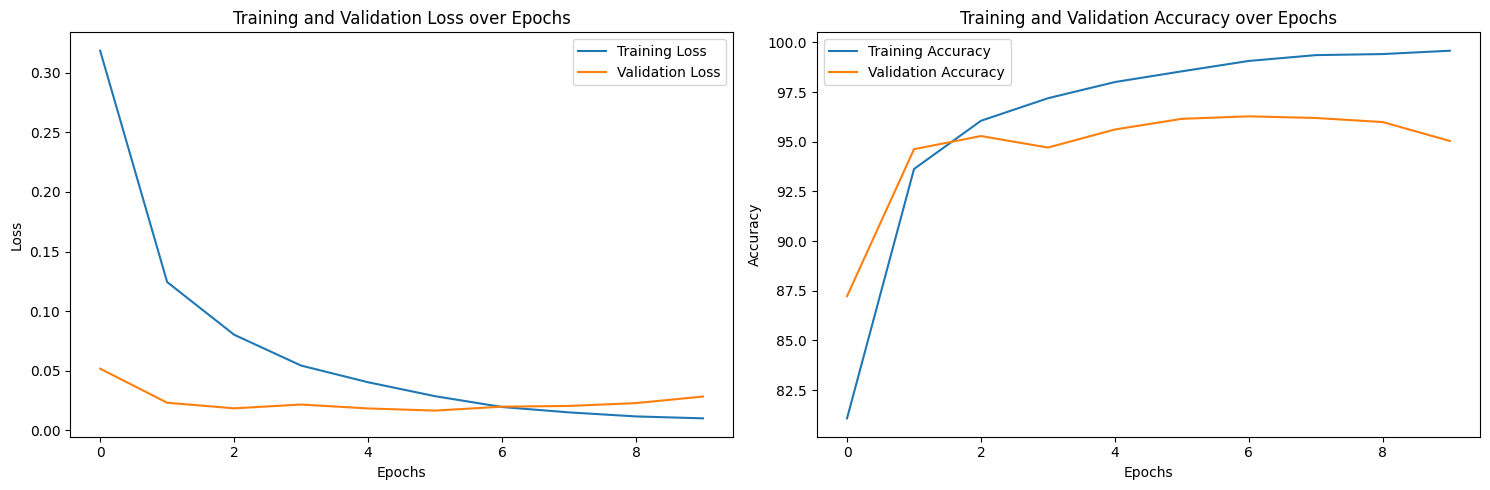

In [18]:

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

plt.show()

In [19]:
def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)

  output = model(image.unsqueeze(0))
  output = torch.argmax(output, axis = 1).item()
  return label_encoder.inverse_transform([output])